In [1]:
import os
os.chdir('../')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
# import nxviz as nv
from networkx.algorithms import community
import warnings
warnings.filterwarnings('ignore')

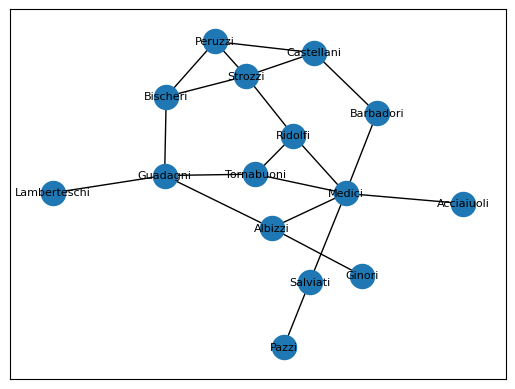

In [3]:
G = nx.florentine_families_graph()
nx.draw_networkx(G, font_size = 8)

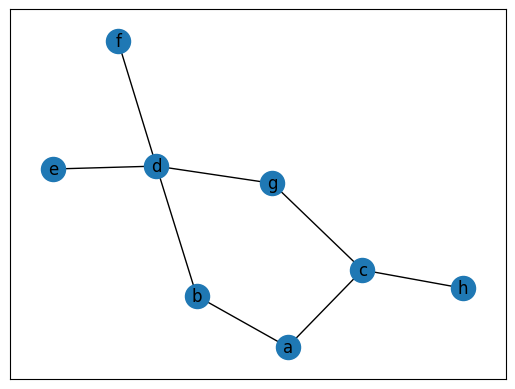

In [4]:
G = nx.Graph()
G.add_edges_from([('a','b'),
                  ('a','c'),
                  ('b','d'),
                  ('c','g'),
                  ('d','e'),
                  ('d','f'),
                  ('d','g'),
                  ('c','h')])
nx.draw_networkx(G)

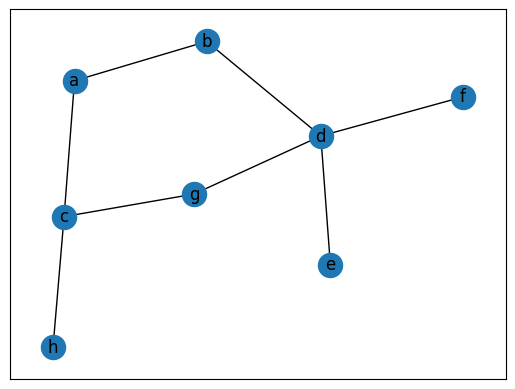

In [5]:
G = nx.Graph()
G.add_edges_from([('a','b'),
                  ('a','c'),
                  ('b','d'),
                  ('c','g'),
                  ('d','e'),
                  ('d','f'),
                  ('d','g'),
                  ('c','h')])
nx.draw_networkx(G)

In [8]:
G.nodes,len(G.nodes)

(NodeView(('a', 'b', 'c', 'd', 'g', 'e', 'f', 'h')), 8)

In [10]:
G.edges

EdgeView([('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'g'), ('c', 'h'), ('d', 'e'), ('d', 'f'), ('d', 'g')])

In [12]:
G.number_of_edges(),G.number_of_nodes()

(8, 8)

In [14]:
df=pd.read_csv('Datasets/edge_list.csv',header=None,names=['x','y'])
G=nx.from_pandas_edgelist(df,'x','y')

In [17]:
# US Cities Network

G=pd.read_pickle('Datasets/major_us_cities')

In [18]:
city_nodes=G.nodes(data=True)

In [20]:
list(city_nodes)[:5]

[('El Paso, TX', {'population': np.int64(674433), 'location': (-106, 31)}),
 ('Long Beach, CA', {'population': np.int64(469428), 'location': (-118, 33)}),
 ('Dallas, TX', {'population': np.int64(1257676), 'location': (-96, 32)}),
 ('Oakland, CA', {'population': np.int64(406253), 'location': (-122, 37)}),
 ('Albuquerque, NM', {'population': np.int64(556495), 'location': (-106, 35)})]

In [21]:
city_edges=G.edges(data=True)
list(city_edges)[:5]

[('El Paso, TX', 'Albuquerque, NM', {'weight': 367.88584356108345}),
 ('El Paso, TX', 'Mesa, AZ', {'weight': 536.256659972679}),
 ('El Paso, TX', 'Tucson, AZ', {'weight': 425.41386739988224}),
 ('El Paso, TX', 'Phoenix, AZ', {'weight': 558.7835703774161}),
 ('El Paso, TX', 'Colorado Springs, CO', {'weight': 797.7517116740046})]

## Network Metrics

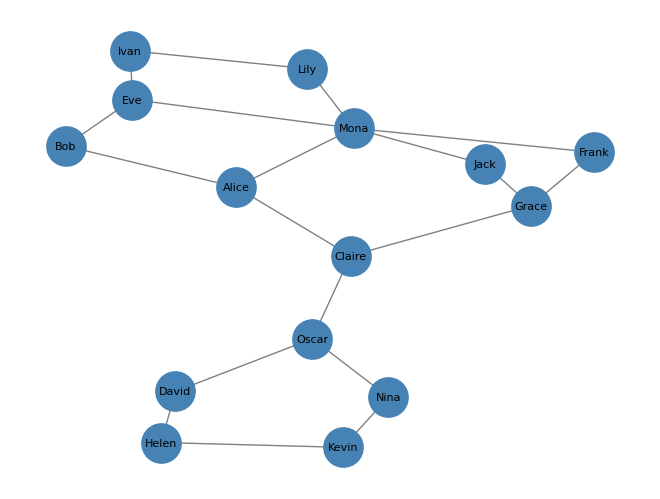

In [22]:
edges = [
    ('Alice', 'Bob'), ('Alice', 'Claire'), 
    ('Bob', 'Eve'),  ('Claire', 'Grace'),
    ('David', 'Helen'), ('Eve', 'Ivan'), ('Frank', 'Grace'),
    ('Grace', 'Jack'), ('Helen', 'Kevin'), ('Ivan', 'Lily'),
    ('Jack', 'Mona'), ('Kevin', 'Nina'), ('Lily', 'Mona'), ('Mona','Frank'),('Mona','Eve'),('Mona','Alice'),
    ('Nina', 'Oscar'), ('Oscar', 'Claire'), ('Oscar', 'David')
]
G = nx.Graph()
G.add_edges_from(edges)
nx.draw(G, 
        pos = nx.spring_layout(G, seed = 1031), 
        with_labels=True, 
        node_color='steelblue', 
        edge_color='gray', 
        node_size=800, 
        font_size=8)
plt.show()

In [23]:
nx.shortest_path(G,'Ivan','Grace')

['Ivan', 'Eve', 'Mona', 'Jack', 'Grace']

In [24]:
nx.shortest_path_length(G,'Ivan','Grace')

4

In [25]:
pd.DataFrame(G.degree,columns=['name','degree']).sort_values(by='degree',ascending=False)

,name,degree
12,Mona,5
2,Claire,3
0,Alice,3
4,Grace,3
3,Eve,3
14,Oscar,3
1,Bob,2
6,Helen,2
5,David,2
7,Ivan,2


In [29]:
nx.eccentricity(G)

{'Alice': 4,
 'Bob': 5,
 'Claire': 4,
 'Eve': 6,
 'Grace': 4,
 'David': 6,
 'Helen': 7,
 'Ivan': 7,
 'Frank': 5,
 'Jack': 5,
 'Kevin': 7,
 'Lily': 6,
 'Mona': 5,
 'Nina': 6,
 'Oscar': 5}

In [34]:
np.mean(list(nx.eccentricity(G).values())),np.max(list(nx.eccentricity(G).values())),np.min(list(nx.eccentricity(G).values()))

(np.float64(5.466666666666667), np.int64(7), np.int64(4))

In [36]:
nx.diameter(G),nx.radius(G)

(7, 4)

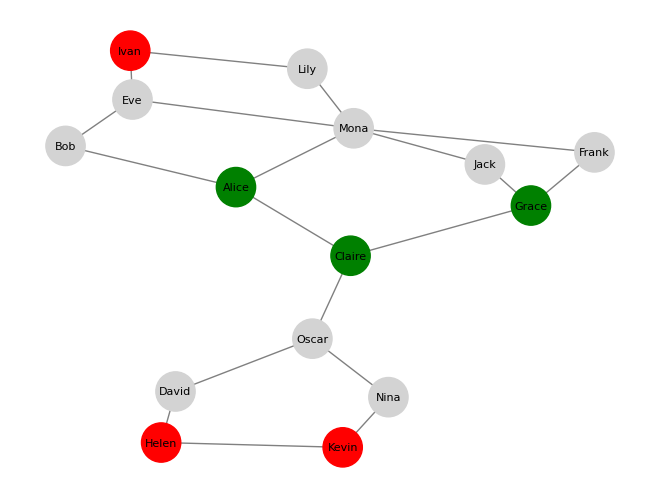

In [37]:
G = nx.Graph()
G.add_edges_from(edges)

node_colors = []
for node in G.nodes():
    if node in set(nx.center(G)):
        node_colors.append('green')       # Center nodes
    elif node in set(nx.periphery(G)):
        node_colors.append('red')         # Periphery nodes
    else:
        node_colors.append('lightgray')   # Neither

nx.draw(G, 
        pos = nx.spring_layout(G, seed = 1031), 
        with_labels=True, 
        node_color=node_colors, 
        edge_color='gray', 
        node_size=800, 
        font_size=8)

plt.show()

In [38]:
nx.average_shortest_path_length(G)

3.019047619047619

## Triadic Closure

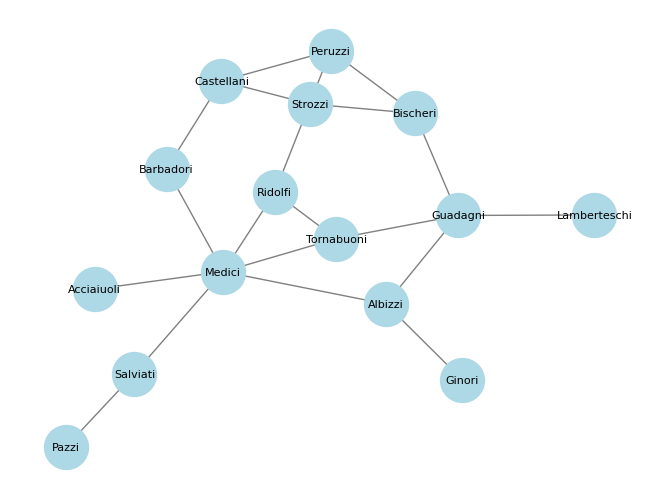

In [39]:
G = nx.florentine_families_graph()
nx.draw(G, 
        pos = nx.spring_layout(G, seed = 1031), 
        with_labels=True, 
        node_color='lightblue', 
        edge_color='gray', 
        node_size=1000, 
        font_size=8)
plt.show()

In [ ]:
# The value is clustering coefficient which is calculated by the number of triangles for a node/degree of that node

nx.clustering(G)

{'Acciaiuoli': 0,
 'Medici': 0.06666666666666667,
 'Castellani': 0.3333333333333333,
 'Peruzzi': 0.6666666666666666,
 'Strozzi': 0.3333333333333333,
 'Barbadori': 0,
 'Ridolfi': 0.3333333333333333,
 'Tornabuoni': 0.3333333333333333,
 'Albizzi': 0,
 'Salviati': 0,
 'Pazzi': 0,
 'Bischeri': 0.3333333333333333,
 'Guadagni': 0,
 'Ginori': 0,
 'Lamberteschi': 0}

In [41]:
nx.closeness_centrality(G,
                        wf_improved=True)  # This is to adjust the measure for situations with more than one component
                                           # Does not impact a graph with a single component

{'Acciaiuoli': 0.3684210526315789,
 'Medici': 0.56,
 'Castellani': 0.3888888888888889,
 'Peruzzi': 0.3684210526315789,
 'Strozzi': 0.4375,
 'Barbadori': 0.4375,
 'Ridolfi': 0.5,
 'Tornabuoni': 0.4827586206896552,
 'Albizzi': 0.4827586206896552,
 'Salviati': 0.3888888888888889,
 'Pazzi': 0.2857142857142857,
 'Bischeri': 0.4,
 'Guadagni': 0.4666666666666667,
 'Ginori': 0.3333333333333333,
 'Lamberteschi': 0.32558139534883723}

In [42]:
nx.betweenness_centrality(G,
                          normalized = True)  # To control for graph size. Large graphs with many nodes will have high betweenness centrality measures. 

{'Acciaiuoli': 0.0,
 'Medici': 0.521978021978022,
 'Castellani': 0.05494505494505495,
 'Peruzzi': 0.02197802197802198,
 'Strozzi': 0.10256410256410257,
 'Barbadori': 0.09340659340659341,
 'Ridolfi': 0.11355311355311355,
 'Tornabuoni': 0.09157509157509157,
 'Albizzi': 0.21245421245421245,
 'Salviati': 0.14285714285714288,
 'Pazzi': 0.0,
 'Bischeri': 0.1043956043956044,
 'Guadagni': 0.2545787545787546,
 'Ginori': 0.0,
 'Lamberteschi': 0.0}

In [43]:
df = pd.DataFrame({
    'Degree': nx.degree_centrality(G),
    'Betweenness': nx.betweenness_centrality(G,normalized=True),
    'Closeness': nx.closeness_centrality(G,wf_improved=True),
    'PageRank': nx.pagerank(G)
})
df.sort_values('Betweenness',ascending = False)

,Degree,Betweenness,Closeness,PageRank
Medici,0.428571,0.521978,0.560000,0.145818
Guadagni,0.285714,0.254579,0.466667,0.098399
Albizzi,0.214286,0.212454,0.482759,0.079122
Salviati,0.142857,0.142857,0.388889,0.061303
Ridolfi,0.214286,0.113553,0.500000,0.069574
Bischeri,0.214286,0.104396,0.400000,0.068862
Strozzi,0.285714,0.102564,0.437500,0.088098
Barbadori,0.142857,0.093407,0.437500,0.050301
Tornabuoni,0.214286,0.091575,0.482759,0.071279
Castellani,0.214286,0.054945,0.388889,0.069330


In [44]:
nx.pagerank(G)

{'Acciaiuoli': 0.03065721480230426,
 'Medici': 0.14581844065218277,
 'Castellani': 0.06933028447008721,
 'Peruzzi': 0.06787531774407571,
 'Strozzi': 0.08809849082725613,
 'Barbadori': 0.050300712744633685,
 'Ridolfi': 0.06957417099014798,
 'Tornabuoni': 0.07127928374676082,
 'Albizzi': 0.07912150238072899,
 'Salviati': 0.061302640987807314,
 'Pazzi': 0.036054222996734095,
 'Bischeri': 0.0688615381141211,
 'Guadagni': 0.09839859717156549,
 'Ginori': 0.032418257716596434,
 'Lamberteschi': 0.03090932465499793}

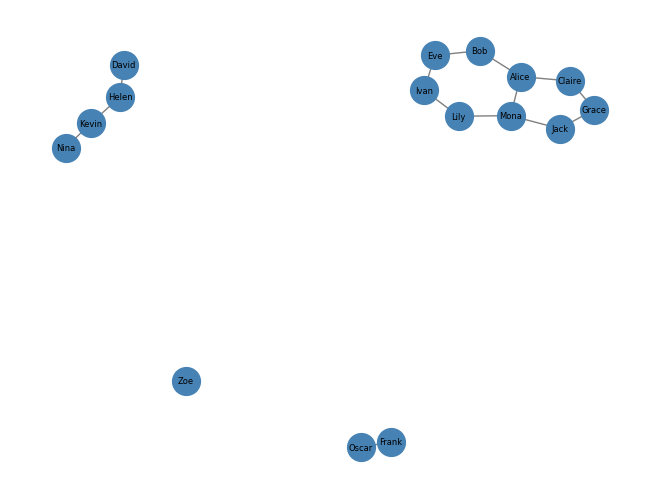

In [45]:
edges = [
    # Component 1
    ('Alice', 'Bob'), ('Alice', 'Claire'), 
    ('Bob', 'Eve'),  ('Claire', 'Grace'), ('Eve', 'Ivan'),
    ('Grace', 'Jack'), ('Ivan', 'Lily'), ('Jack', 'Mona'),
    ('Lily', 'Mona'), ('Mona', 'Alice'),

    # Component 2
    ('David', 'Helen'), ('Helen', 'Kevin'), ('Kevin', 'Nina'),

    # Component 3
    ('Oscar', 'Frank'),

    # Isolated node
]

# Build the graph
G = nx.Graph()
G.add_edges_from(edges)
G.add_node('Zoe')  # isolated node

nx.draw(G, 
        pos = nx.spring_layout(G,seed = 617), 
        with_labels=True, 
        node_color='steelblue', 
        edge_color='gray', 
        node_size=400, 
        font_size=6)
plt.show()

In [46]:
edges = [
    ('Alice', 'Bob'), ('Alice', 'Claire'), 
    ('Bob', 'Eve'),  ('Claire', 'Grace'),
    ('David', 'Helen'), ('Eve', 'Ivan'), ('Frank', 'Grace'),
    ('Grace', 'Jack'), ('Helen', 'Kevin'), ('Ivan', 'Lily'),
    ('Jack', 'Mona'), ('Kevin', 'Nina'), ('Lily', 'Mona'), ('Mona','Frank'),('Mona','Eve'),('Mona','Alice'),
    ('Nina', 'Oscar'), ('Oscar', 'Claire'), ('Oscar', 'David')
]
G = nx.Graph()
G.add_edges_from(edges)
from networkx.algorithms.community import greedy_modularity_communities
communities = greedy_modularity_communities(G)
communities

[frozenset({'Claire', 'David', 'Helen', 'Kevin', 'Nina', 'Oscar'}),
 frozenset({'Alice', 'Bob', 'Eve', 'Ivan', 'Lily'}),
 frozenset({'Frank', 'Grace', 'Jack', 'Mona'})]

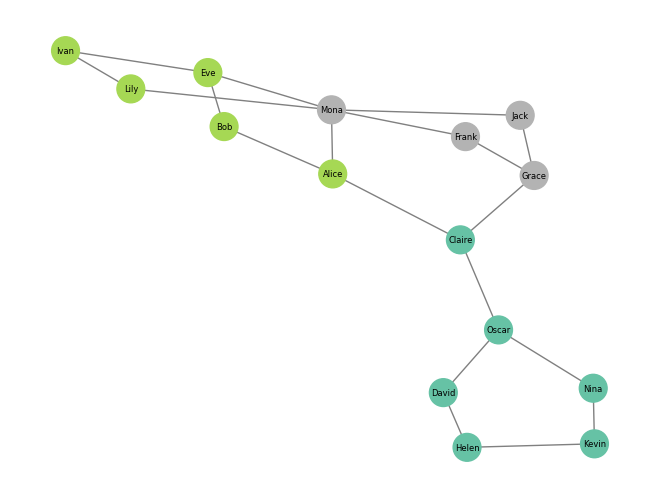

In [47]:
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i
colors = [color_map[node] for node in G.nodes]
nx.draw(G, 
        pos = nx.spring_layout(G,seed = 617), 
        with_labels=True, 
        node_color=colors, 
        edge_color='gray', 
        node_size=400, 
        font_size=6,
        cmap = plt.cm.Set2)
plt.show()

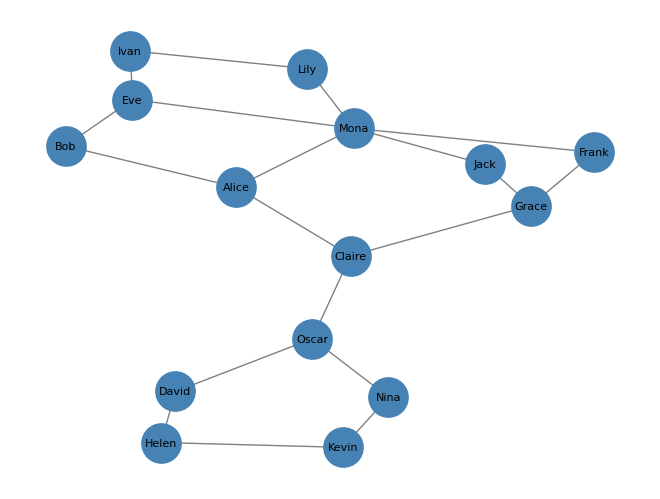

In [48]:
edges = [
    ('Alice', 'Bob'), ('Alice', 'Claire'), 
    ('Bob', 'Eve'),  ('Claire', 'Grace'),
    ('David', 'Helen'), ('Eve', 'Ivan'), ('Frank', 'Grace'),
    ('Grace', 'Jack'), ('Helen', 'Kevin'), ('Ivan', 'Lily'),
    ('Jack', 'Mona'), ('Kevin', 'Nina'), ('Lily', 'Mona'), ('Mona','Frank'),('Mona','Eve'),('Mona','Alice'),
    ('Nina', 'Oscar'), ('Oscar', 'Claire'), ('Oscar', 'David')
]
G = nx.Graph()
G.add_edges_from(edges)
nx.draw(G, 
        pos = nx.spring_layout(G, seed = 1031), 
        with_labels=True, 
        node_color='steelblue', 
        edge_color='gray', 
        node_size=800, 
        font_size=8)
plt.show()

In [49]:
nx.common_neighbors(G, 'Claire','Mona')

{'Alice'}

In [50]:
nx.common_neighbors(G, 'Eve','Lily')

{'Ivan', 'Mona'}

In [51]:
neighbors = [(e[0], e[1], len(nx.common_neighbors(G,e[0],e[1]))) for e in nx.non_edges(G)]
df = pd.DataFrame(neighbors, columns=['name1','name2','common_neighbors'])
df = df.set_index(['name1','name2'])

In [52]:
df

common_neighbors
name1 name2                  
Ivan  Grace                 0
      Kevin                 0
      Helen                 0
      Bob                   1
      Frank                 0
...                       ...
David Jack                  0
      Eve                   0
Lily  Jack                  1
      Eve                   2
Jack  Eve                   1

[86 rows x 1 columns]

In [53]:
list(nx.jaccard_coefficient(G))[:5]


[('Ivan', 'Grace', 0.0),
 ('Ivan', 'Kevin', 0.0),
 ('Ivan', 'Helen', 0.0),
 ('Ivan', 'Bob', 0.3333333333333333),
 ('Ivan', 'Frank', 0.0)]

In [54]:
df['jaccard'] =  [x for name1, name2, x in nx.jaccard_coefficient(G)]

In [55]:
df

common_neighbors   jaccard
name1 name2                            
Ivan  Grace                 0  0.000000
      Kevin                 0  0.000000
      Helen                 0  0.000000
      Bob                   1  0.333333
      Frank                 0  0.000000
...                       ...       ...
David Jack                  0  0.000000
      Eve                   0  0.000000
Lily  Jack                  1  0.333333
      Eve                   2  0.666667
Jack  Eve                   1  0.250000

[86 rows x 2 columns]

In [56]:
list(nx.preferential_attachment(G))[:5]

[('Ivan', 'Grace', 6),
 ('Ivan', 'Kevin', 4),
 ('Ivan', 'Helen', 4),
 ('Ivan', 'Bob', 4),
 ('Ivan', 'Frank', 4)]

In [57]:
df['preferential_attachment'] =  [x for name1, name2, x in nx.preferential_attachment(G)]
df.sort_values(['preferential_attachment'], ascending=False).head()

,,common_neighbors,jaccard,preferential_attachment
name1,name2,,,
Grace,Mona,2,0.333333,15
Claire,Mona,1,0.142857,15
Oscar,Mona,0,0.000000,15
Kevin,Mona,0,0.000000,10
Helen,Mona,0,0.000000,10
